# Load Packages

In [1]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
# using Distributions
using LsqFit
using BlackBoxOptim
using LaTeXStrings
using JLD2
using KernelDensity
using XLSX
using Dates
using Statistics
# using Distributions
using OrdinaryDiffEq
using LsqFit
using BlackBoxOptim
using LaTeXStrings
using KernelDensity
using Polynomials 
using Trapz

# Extract Data

In [2]:
mainpath = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\LDHActivityAssay\\";
flss = ["DGC_LMF_PS_LDHAssey_Rep1_0mM", "DGC_LMF_PS_LDHAssey_Rep2_01mM", "DGC_LMF_PS_LDHAssey_Rep2_02mM", "DGC_LMF_PS_LDHAssey_Rep2_03mM", "DGC_LMF_PS_LDHAssey_Rep1_04mM", 
        "DGC_LMF_PS_LDHAssey_Rep1_05mM", "DGC_LMF_PS_LDHAssey_Rep1_1mM", "DGC_LMF_PS_LDHAssey_Rep1_2mM", 
        "DGC_LMF_PS_LDHAssey_Rep1_3mM", "DGC_LMF_PS_LDHAssey_Rep1_4mM", "DGC_LMF_PS_LDHAssey_Rep1_5mM", "DGC_LMF_PS_LDHAssey_Rep1_10mM", "DGC_LMF_PS_LDHAssey_Rep1_20mM", 
        "DGC_LMF_PS_LDHAssey_Rep1_30mM", "DGC_LMF_PS_LDHAssey_Rep1_40mM", "DGC_LMF_PS_LDHAssey_Rep1_60mM", "DGC_LMF_PS_LDHAssey_Rep1_80mM", "DGC_LMF_PS_LDHAssey_Rep1_100mM", "DGC_LMF_PS_LDHAssey_Rep1_120mM", 
        "DGC_LMF_PS_LDHAssey_Rep1_140mM", "DGC_LMF_PS_LDHAssey_Rep1_160mM"];

cntl = "DGC_LMF_PS_LDHAssey_Rep1_PyrControl"
cntl2 = "DGC_LMF_PS_LDHAssey_Rep1_SmallPyrControl"

dat = Array{Any}(undef, length(flss))

dels = Array{Any}(undef, length(flss))

for i in 1:length(dat)
    tmp1 = XLSX.readxlsx(mainpath*flss[i]*".xlsx")
    tmp2 = tmp1[XLSX.sheetnames(tmp1)[1]]
    dat[i] = tmp2["B43:K54"]
    dels[i] = tmp2["M43"][1:2]
end

tmp1 = XLSX.readxlsx(mainpath*cntl*".xlsx")
tmp2 = tmp1[XLSX.sheetnames(tmp1)[1]]
cntlDat = tmp2["C28:N35"];

tmp1 = XLSX.readxlsx(mainpath*cntl2*".xlsx")
tmp2 = tmp1[XLSX.sheetnames(tmp1)[1]]
cntlDat2 = tmp2["F33:I34"];

# Extract Pyruvate Background at 340nm for correction

In [3]:
cns = [0,0.1,0.2,0.3,0.4,0.5,1,2,3,4,5,10,20,30,40,60,80,100, 120,140,160];

pyrBKG = vcat(mean(cntlDat[2, 2:4]), 
              transpose(mean(cntlDat2[:,1:4], dims=1)), 
              mean(cntlDat[3:end-1, 2:4], dims=2), 
              mean(cntlDat[2:end-2, 6:8], dims=2), 
              mean(cntlDat[2:end-1, 10:12], dims=2));

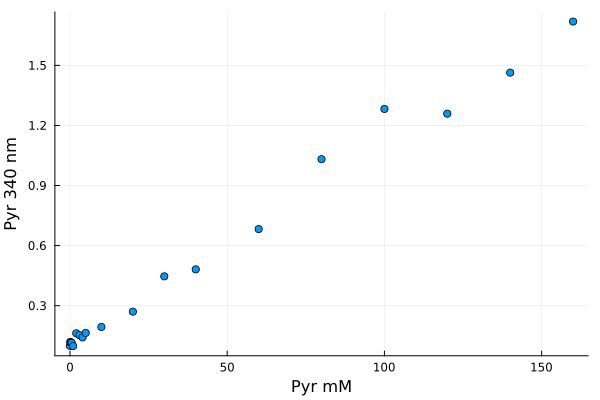

In [5]:
scatter(cns, pyrBKG, label = "", xlabel = "Pyr mM", ylabel = "Pyr 340 nm")

# Extract NADH consumption data (corrected) and Display

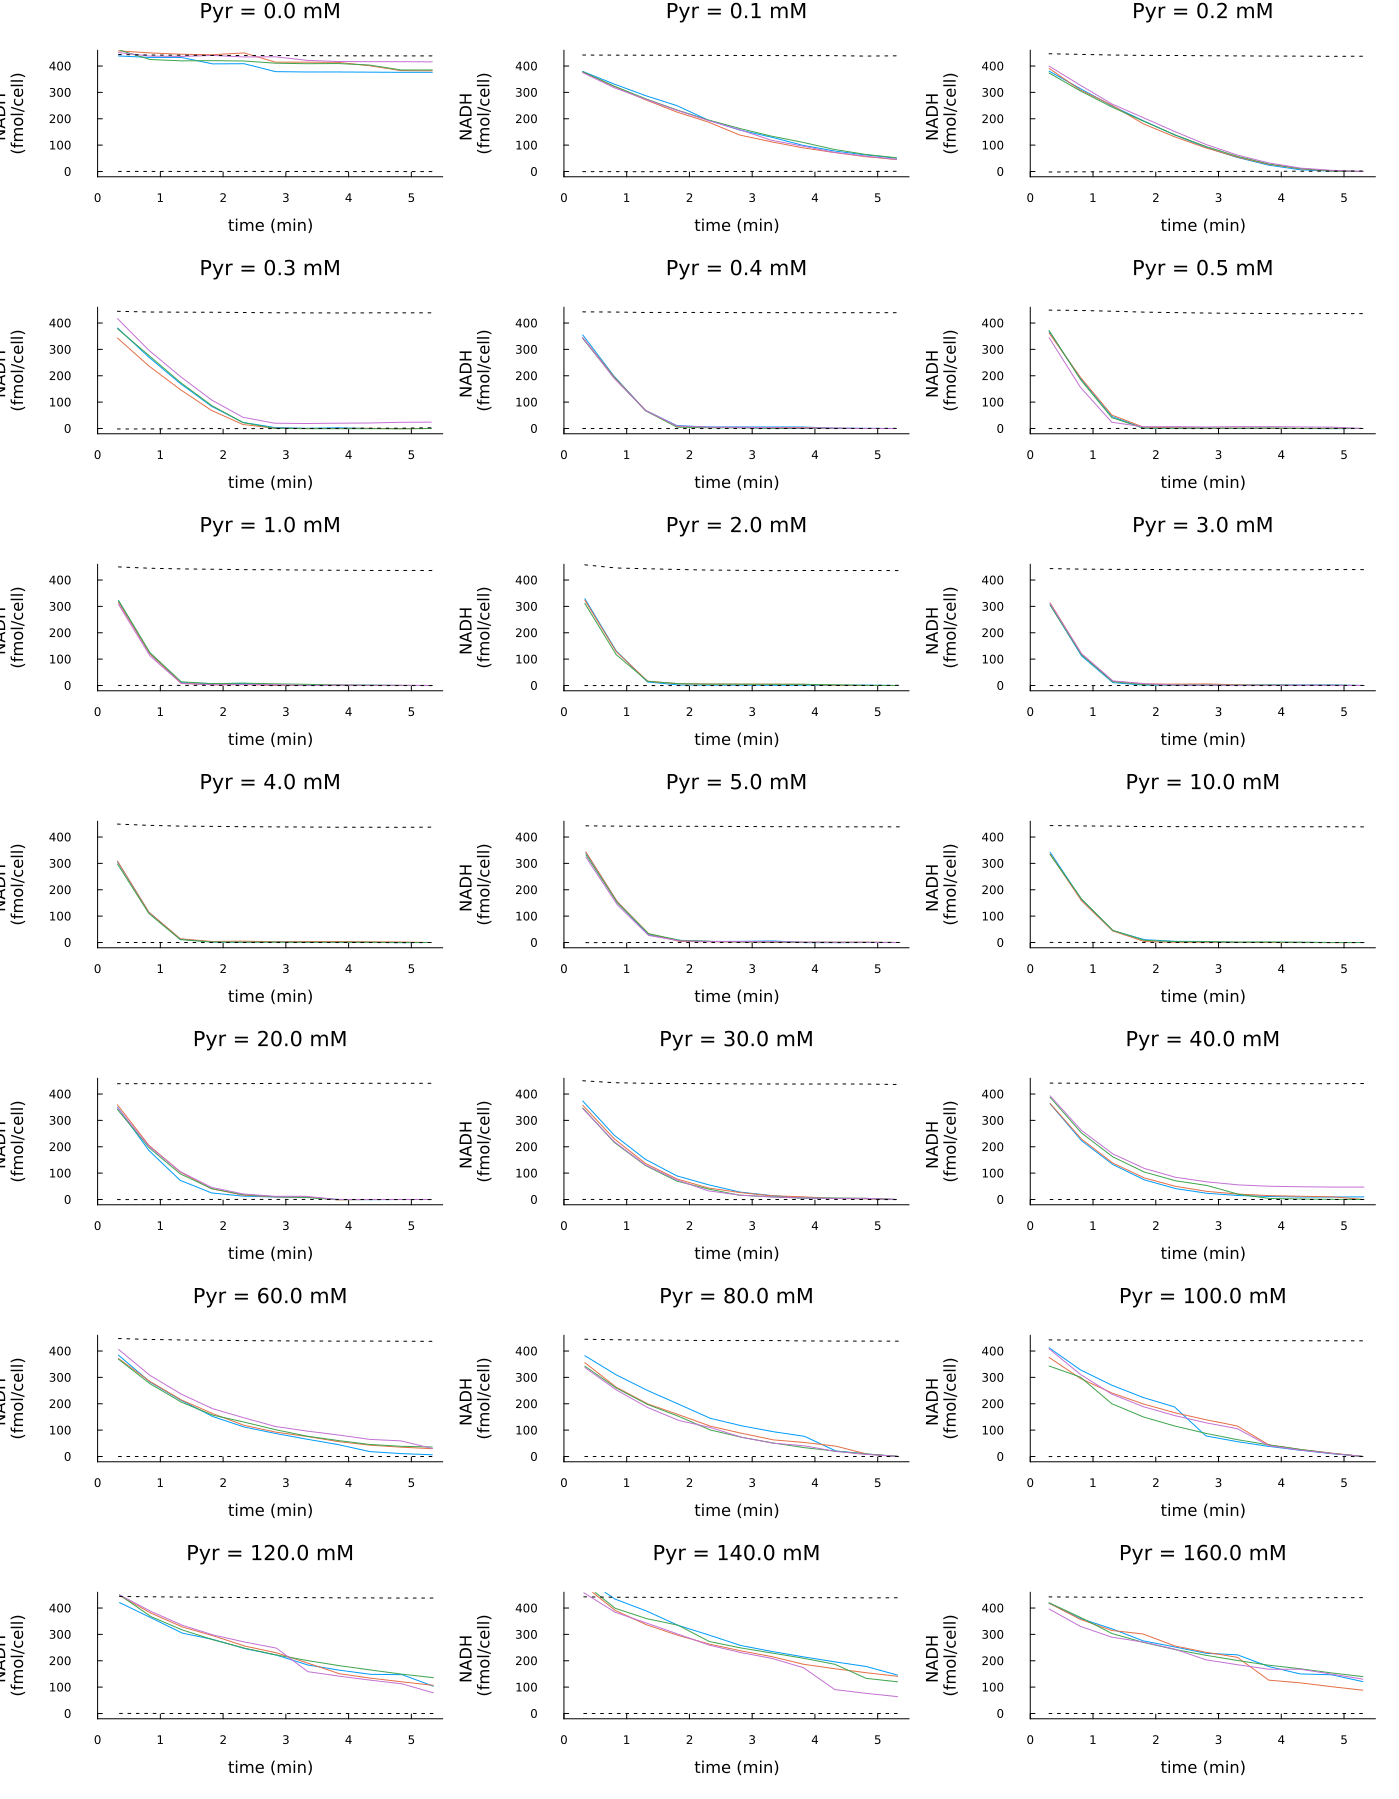

In [ ]:

timVecs = [(parse.(Float64, dels)./60)[k]  .+ collect(0:0.5:5) for k in 1:length(dels)];


PPT = Array{Any}(undef, length(cns))

rats = zeros(2,length(cns))

allRats = Dict();

for i in 1:length(cns)

    conc = dat[i][2:end,3:6]
    poscn = mean(dat[i][2:end,7:8], dims=2)
    negcn = mean(dat[i][2:end, 9:10], dims=2)

    ppt = plot(grid=false, title = "Pyr = "*string(cns[i])*" mM", ylabel = "NADH \n(fmol/cell)", xlabel="time (min)", ylim = (-0.1*200,2.3*200), xlim=(0,5.5))


    cordat = (conc.-transpose(pyrBKG[i]))
    cordatMolar = zeros(size(cordat))
    cordatMol = zeros(size(cordat))

    for j in 1:4
        
        if cordat[end,j] < mean(negcn) 
            tmp = abs(cordat[end,j] - mean(negcn))
            cordat[:,j] = cordat[:,j].+tmp
        end


        cordatMolar[:,j] = ((cordat[:,j] .- mean(negcn))./(mean(poscn)-mean(negcn))) .* 220 # This will be in micromolar
        
        # First convert to number of molecules instead of concentration and then normalise to number of cells. 
        cordatMol[:,j] = ((cordatMolar[:,j].*0.0002) / 10^5) .* 1e9 # Convert to femtomoles per cell

        if (i == 8 && j == 3) || (i == 10 && j == 3) || (i == 12 && j == 4)
            nothing
        else
            plot!(timVecs[i], cordatMol[:,j], label = "")
        end


    end

    
    upp = ((mean(poscn, dims=2) .- mean(negcn))./(mean(poscn)-mean(negcn))) .* 220
    dwn = ((mean(negcn, dims=2) .- mean(negcn))./(mean(poscn)-mean(negcn))) .* 220


    # tmpdat = zeros(length(timVecs[i]), 7)

    # tmpdat[:,1] = timVecs[i]
    # tmpdat[:,2] = ((dwn.*2e-4) / 10^5) .* 1e9
    # tmpdat[:,3] = ((upp.*2e-4) / 10^5) .* 1e9

    # tmpdat[:,4] = cordatMol[:,1]
    # tmpdat[:,5] = cordatMol[:,2]
    # tmpdat[:,6] = cordatMol[:,3]
    # tmpdat[:,7] = cordatMol[:,4]

    # CSV.write("E:\\IBEC\\KineticRates\\LDHActivityAssay\\DataNADH_fmol-cell_Pyr"*string(cns[i])*".csv", DataFrame(tmpdat, ["time (min)","-c","+c","Rep1","Rep2","Rep3","Rep4"]))



    plot!(timVecs[i], ((upp.*2e-4) / 10^5) .* 1e9, label ="", colour="black", linestyle =:dot)
    plot!(timVecs[i], ((dwn.*2e-4) / 10^5) .* 1e9, label ="", colour="black", linestyle =:dot)

    PPT[i] = ppt


    if (i == 8) || (i == 10)
        rats[1,i] = mean((cordatMol[1,[1,2,4]] .- cordatMol[2,[1,2,4]])./0.5)
        rats[2,i] = std((cordatMol[1,[1,2,4]] .- cordatMol[2,[1,2,4]])./0.5)
        allRats[cns[i]] = (cordatMol[1,[1,2,4]] .- cordatMol[2,[1,2,4]])./0.5
    elseif (i == 12)
        rats[1,i] = mean((cordatMol[1,[1,2,3]] .- cordatMol[2,[1,2,3]])./0.5)
        rats[2,i] = std((cordatMol[1,[1,2,3]] .- cordatMol[2,[1,2,3]])./0.5)
        allRats[cns[i]] = (cordatMol[1,[1,2,3]] .- cordatMol[2,[1,2,3]])./0.5
    else
        rats[1,i] = mean((cordatMol[1,:] .- cordatMol[2,:])./0.5)
        rats[2,i] = std((cordatMol[1,:] .- cordatMol[2,:])./0.5)

        allRats[cns[i]] = (cordatMol[1,:] .- cordatMol[2,:])./0.5
    end



end

PPT2 = plot(PPT..., size=(1400,1800), layout=(7,3), margin = 4mm)

# savefig(PPT2,"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\SuppFig27Stuff\\NADConsumption.svg")

display(PPT2)

# Display Pyruvate VS NADH consumption rate

[51.647244105077476, 7.486283267146228, 0.008937299958298018, -7.2952507331194445, 3.2552901271557353]


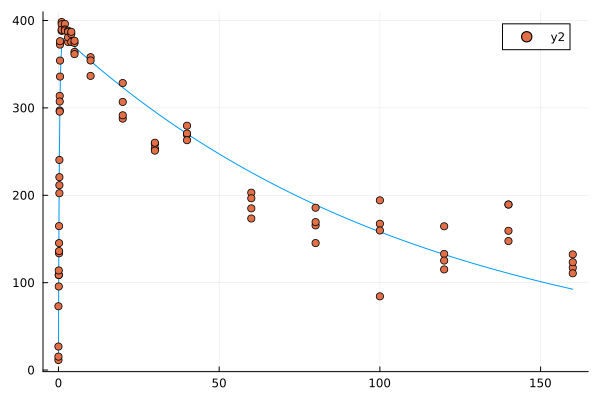

In [48]:
ststog = []
cnstog = []
for i in 1:length(cns)
    [push!(ststog, allRats[cns[i]][k]) for k in 1:length(allRats[cns[i]])]
    [push!(cnstog, cns[i]) for k in 1:length(allRats[cns[i]])]
end


pp = [51.647244099004276, 7.486283266112995, 0.008937299968085512, -7.295250735991465, 3.255290174597373]

ss(t,p) = p[1].*(p[2].*exp.(-t.*p[3]).+p[4].*exp.(-t.*p[5]))

fitt = LsqFit.curve_fit(ss, cnstog, ststog, pp, maxIter=1000000, x_tol = 1e-7, g_tol = 1e-7)


println(coef(fitt))
scatter(cnstog, ststog)
plot(0:0.1:160, ss(0:0.1:160, coef(fitt)), label="")
scatter!(cnstog, ststog)

In [49]:
# nRMSE (Does not include the 0, since the low noise in that experiment has a really high effect, masking the rest of the experiments)
fftc = ss(cns, coef(fitt))
nRMSE = sum((rats[1,2:end]*1000 - fftc[2:end]*1000).^2 ./ (rats[2,2:end]*1000).^2)/length(fftc[2:end]) + log(5*log(length(fftc[2:end])))

11.65037409321145

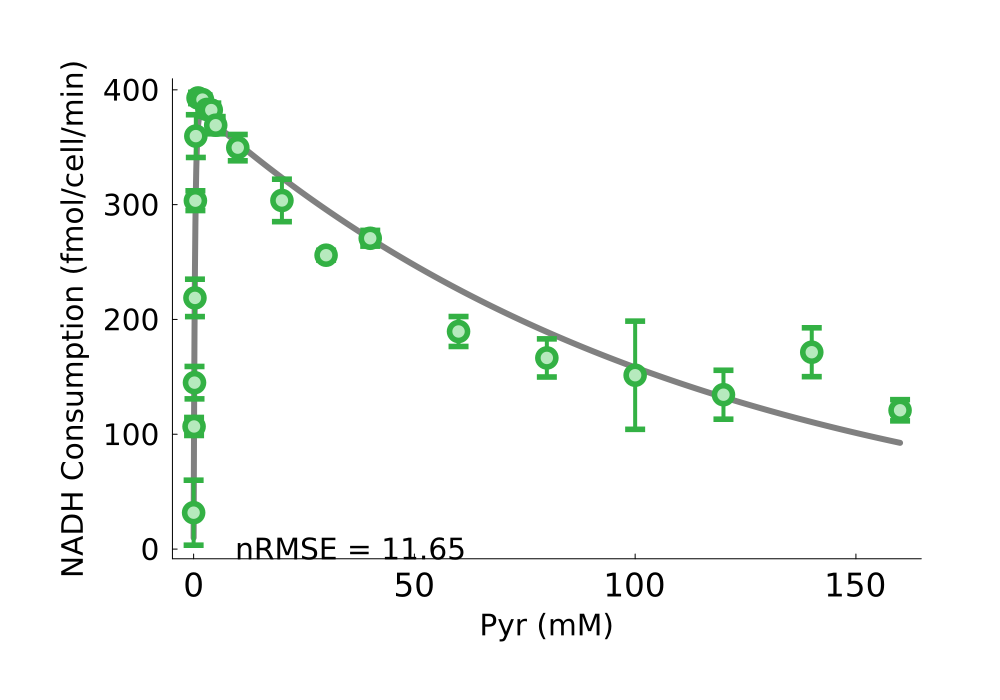

In [50]:
ppt = plot(grid=false, linewidth=6, size = (1000,700), xtickfont=font(22), ytickfont=font(20), margins=18Plots.mm, guidefontsize = 20)


plot!(0:0.1:160, ss(0:0.1:160, coef(fitt)), label="", linewidth=6, colour="gray")

# scatter!(cns[2:end], rats[1,2:end], yerror = rats[2,2:end], label="", ylabel = "NADH (fmol/cell/min)", xlabel="Pyr (mM)", xscale=:log10)
scatter!(cns[:], rats[1,:], yerror = rats[2,:], label="", ylabel = "NADH Consumption (fmol/cell/min)", xlabel="Pyr (mM)", markersize = 10, markerstrokewidth=4, 
        color="#b6eabdff", markerstrokecolor="#33b144ff")

annotate!(10, 0.5, text("nRMSE = "*string(round(nRMSE, digits = 2)),  :black, :left, 20))

savefig(ppt,"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\Figures\\SuppFig26Stuff\\LacVsPyrDat_LDHAssay.svg")

display(ppt)

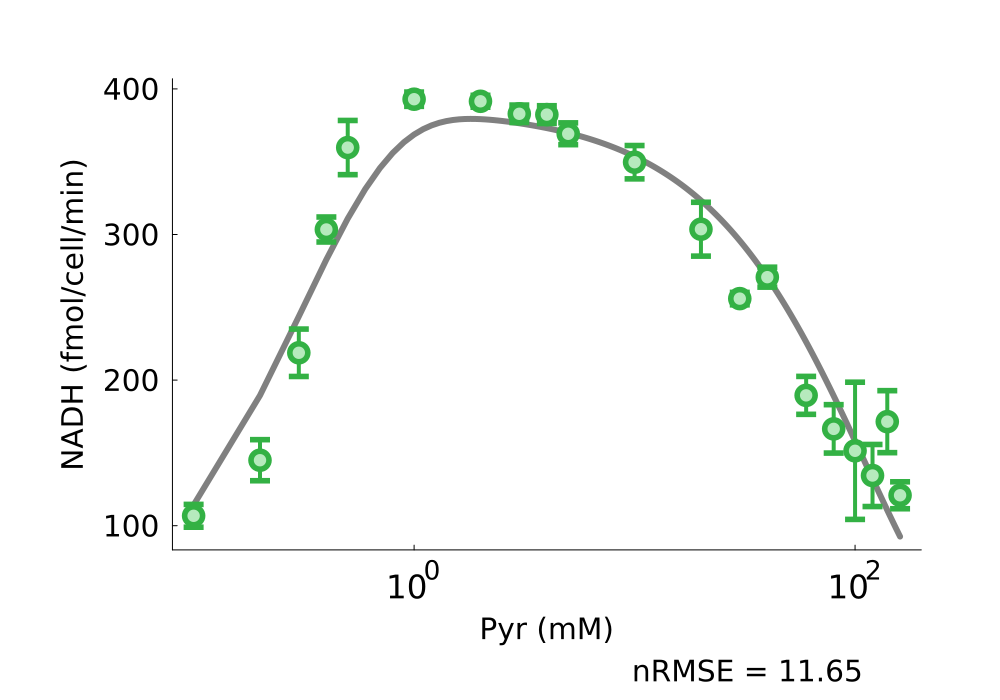

In [51]:
ppt = plot(grid=false, linewidth=6, size = (1000,700), xtickfont=font(22), ytickfont=font(20), margins=18Plots.mm, guidefontsize = 20)


plot!(0.1:0.1:160, ss(0.1:0.1:160, coef(fitt)), label="", linewidth=6, colour="gray")

scatter!(cns[2:end], rats[1,2:end], yerror = rats[2,2:end], label="", ylabel = "NADH (fmol/cell/min)", xlabel="Pyr (mM)", xscale=:log10, markersize = 10, markerstrokewidth=4, 
        color="#b6eabdff", markerstrokecolor="#33b144ff")
# scatter!(cns[1:14], rats[1,1:14], yerror = rats[2,1:10], label="", ylabel = "NADH (fmol/cell/min)", xlabel="Pyr (mM)")


annotate!(10, 0.5, text("nRMSE = "*string(round(nRMSE, digits = 2)),  :black, :left, 20))



display(ppt)

In [52]:
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\LDHActivityAssey\\Results\\LDHActivityResults.csv", 
        DataFrame(hcat(cns, rats[1,:], rats[2,:]), ["Pyr (mM)", "NADH Consumption Mean (fmol/cell/min)", "NADH Consumption STD (fmol/cell/min)"]))

"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\LDHActivityAssey\\Results\\LDHActivityResults.csv"